# J1 · Part A — Fraud detection with a tree ensemble

**Track J: AI/ML Modeling — J1 Supervised & Unsupervised Learning**

**Objective.** Train a tree ensemble (XGBoost) on a labeled dataset, tune its basic parameters, and show — with a comparison table — whether it beats a naive baseline and a simpler model.

**Data.** [PaySim](https://www.kaggle.com/datasets/ealaxi/paysim1) synthetic mobile-money transactions: 6,362,620 rows, label `isFraud`. Fraud is extremely rare (about 0.13%), so the evaluation has to be chosen with care.

**Approach in one paragraph.** Explore the data and decide what to model (§2). Build features and a train / validation / test split (§3). Fit baselines — a naive "never fraud" model, the simulator's own `isFlaggedFraud` rule, and logistic regression (§4). Tune and fit XGBoost (§5). Compare everything on the untouched test set, run an ablation, a bootstrap confidence interval and a robustness check (§6). State the conclusion and the limits (§7).

**Metrics.** Accuracy is meaningless here (predicting "not fraud" every time scores >99.8%). The headline metric is **PR-AUC** (average precision), supported by recall, precision and F1 at a threshold chosen on the validation set.

| § | Section |
|---|---|
| 1 | Setup and loading |
| 2 | Exploratory analysis and scoping |
| 3 | Features and split |
| 4 | Baselines |
| 5 | XGBoost: tuning and final fit |
| 6 | Comparison, ablation, confidence interval, robustness |
| 7 | Conclusions and limitations |

## 1. Setup and loading

In [1]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import Markdown, display

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve, confusion_matrix
from xgboost import XGBClassifier

SEED = 42
ROOT = Path("..") if Path("../data").exists() else Path(".")
DATA_FILE = ROOT / "data" / "PS_20174392719_1491204439457_log.csv"
REPORT_DIR = ROOT / "reports"
FIG_DIR = REPORT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

**Chart style.** One palette throughout (validated for colour-blind separation): blue = XGBoost, aqua = logistic regression, yellow = rule baseline, grey = naive baseline, orange = fraud-related quantities. Every multi-series chart has a legend and the numbers are also available as tables.

In [2]:
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 11.5, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "lines.linewidth": 2, "lines.solid_capstyle": "round",
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "legend.frameon": False, "figure.dpi": 110,
})


def save_fig(fig, name):
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")


thousands = FuncFormatter(lambda v, _: f"{v:,.0f}")
percent = FuncFormatter(lambda v, _: f"{v:.0%}")

**Loading.** The CSV is 470 MB and about 1.5 GB in memory with default types. Only the columns we need are read, with compact types. `nameOrig` / `nameDest` are customer and merchant identifiers; they are checked below and then excluded.

In [3]:
cols = ["step", "type", "amount", "oldbalanceOrg", "newbalanceOrig",
        "oldbalanceDest", "newbalanceDest", "isFraud", "isFlaggedFraud"]
dtypes = {"step": "int16", "type": "category", "isFraud": "int8", "isFlaggedFraud": "int8"}

t0 = time.time()
df = pd.read_csv(DATA_FILE, usecols=cols, dtype=dtypes)
print(f"Loaded {len(df):,} rows x {df.shape[1]} columns in {time.time() - t0:.1f}s "
      f"({df.memory_usage(deep=True).sum() / 1e6:,.0f} MB in memory)")
print(f"Missing values: {int(df.isna().sum().sum())}   |   Rows identical to another row (identifier columns not loaded): {int(df.duplicated().sum()):,}")
df.head()

Loaded 6,362,620 rows x 9 columns in 10.8s (286 MB in memory)


Missing values: 0   |   Rows identical to another row (identifier columns not loaded): 543


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.6400","170,136.0000","160,296.3600",0.0000,0.0000,0,0
1,1,PAYMENT,"1,864.2800","21,249.0000","19,384.7200",0.0000,0.0000,0,0
2,1,TRANSFER,181.0000,181.0000,0.0000,0.0000,0.0000,1,0
3,1,CASH_OUT,181.0000,181.0000,0.0000,"21,182.0000",0.0000,1,0
4,1,PAYMENT,"11,668.1400","41,554.0000","29,885.8600",0.0000,0.0000,0,0


In [4]:
# Why the identifier columns are dropped: they are (almost) unique per row.
ids = pd.read_csv(DATA_FILE, usecols=["nameOrig", "nameDest"])
print(f"nameOrig unique values: {ids['nameOrig'].nunique():,} of {len(ids):,} rows")
print(f"nameDest unique values: {ids['nameDest'].nunique():,} of {len(ids):,} rows")
del ids

# The "identical rows" counted above are different customers' transactions that only look alike once identifiers are dropped.
same = df[df.duplicated(keep=False)]
same_by_type = same.groupby("type", observed=True)["isFraud"].agg(rows="size", frauds="sum").query("rows > 0")
display(same_by_type)
print(f"{len(same):,} rows belong to groups of identical rows; {int((same['type'] == 'PAYMENT').sum()):,} of them are PAYMENTs (outside the modelling scope, see 2.3). They are kept: they are separate transactions.")

nameOrig unique values: 6,353,307 of 6,362,620 rows


nameDest unique values: 2,722,362 of 6,362,620 rows


,rows,frauds
type,,
CASH_OUT,27,27
PAYMENT,1054,0


1,081 rows belong to groups of identical rows; 1,054 of them are PAYMENTs (outside the modelling scope, see 2.3). They are kept: they are separate transactions.


## 2. Exploratory analysis and scoping

### 2.1 Class imbalance

In [5]:
n_all, n_fraud_all = len(df), int(df["isFraud"].sum())
display(Markdown(
    f"- Transactions: **{n_all:,}**; fraudulent: **{n_fraud_all:,}** (**{n_fraud_all / n_all:.3%}**), i.e. about 1 in {n_all / n_fraud_all:,.0f}.\n"
    f"- A model that **always predicts \"not fraud\" is {1 - n_fraud_all / n_all:.2%} accurate** while catching 0 frauds, so accuracy cannot be used to judge anything here. "
    f"This is why the headline metric is PR-AUC and why a naive baseline is part of the comparison."
))

- Transactions: **6,362,620**; fraudulent: **8,213** (**0.129%**), i.e. about 1 in 775.
- A model that **always predicts "not fraud" is 99.87% accurate** while catching 0 frauds, so accuracy cannot be used to judge anything here. This is why the headline metric is PR-AUC and why a naive baseline is part of the comparison.

### 2.2 Where does fraud happen?

,transactions,frauds,fraud_rate
type,,,
CASH_OUT,"2,237,500","4,116",0.1840%
PAYMENT,"2,151,495",0,0.0000%
CASH_IN,"1,399,284",0,0.0000%
TRANSFER,"532,909","4,097",0.7688%
DEBIT,"41,432",0,0.0000%


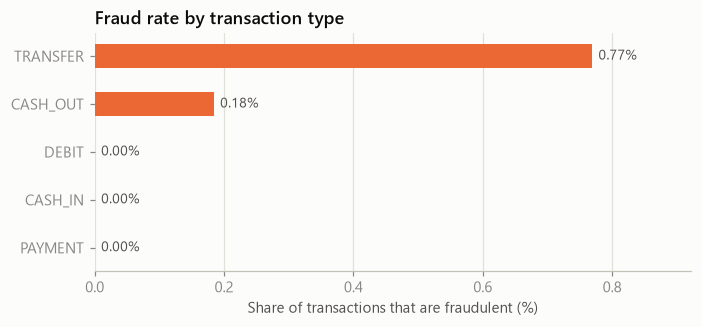

In [6]:
by_type = (df.groupby("type", observed=True)["isFraud"]
             .agg(transactions="size", frauds="sum")
             .assign(fraud_rate=lambda t: t["frauds"] / t["transactions"])
             .sort_values("transactions", ascending=False))
display(by_type.style.format({"transactions": "{:,}", "frauds": "{:,}", "fraud_rate": "{:.4%}"}))

fig, ax = plt.subplots(figsize=(7, 2.8))
order = by_type.sort_values("fraud_rate").index
rates = by_type.loc[order, "fraud_rate"]
ax.barh(order.astype(str), rates * 100, height=0.5, color=ORANGE)
for i, v in enumerate(rates):
    ax.text(v * 100 + 0.01, i, f"{v:.2%}", va="center", color=INK_2, fontsize=9)
ax.set_title("Fraud rate by transaction type")
ax.set_xlabel("Share of transactions that are fraudulent (%)")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, rates.max() * 100 * 1.2)
save_fig(fig, "fraud_rate_by_type.png")
plt.show()

### 2.3 Scoping decision

Fraud occurs **only** in `TRANSFER` and `CASH_OUT` transactions; `CASH_IN`, `DEBIT` and `PAYMENT` contain no fraud at all. A model has nothing to learn from those types, so the supervised problem is defined on `TRANSFER` + `CASH_OUT` only. All reported metrics are on that subset. Transactions of the other three types can be labelled "not fraud" with no loss in this data.

In [7]:
d = df[df["type"].isin(["TRANSFER", "CASH_OUT"])].reset_index(drop=True)
d["type"] = d["type"].cat.remove_unused_categories()
frauds_kept = int(d["isFraud"].sum())
display(Markdown(
    f"- Rows kept: **{len(d):,}** of {n_all:,} ({len(d) / n_all:.1%}).\n"
    f"- Frauds kept: **{frauds_kept:,}** of {n_fraud_all:,} (**{frauds_kept / n_fraud_all:.0%}** of all fraud).\n"
    f"- Fraud rate inside the scope: **{frauds_kept / len(d):.3%}**."
))

- Rows kept: **2,770,409** of 6,362,620 (43.5%).
- Frauds kept: **8,213** of 8,213 (**100%** of all fraud).
- Fraud rate inside the scope: **0.296%**.

### 2.4 Structure over time

`step` is one simulated hour (743 steps ≈ 31 days). This matters for how we split the data.

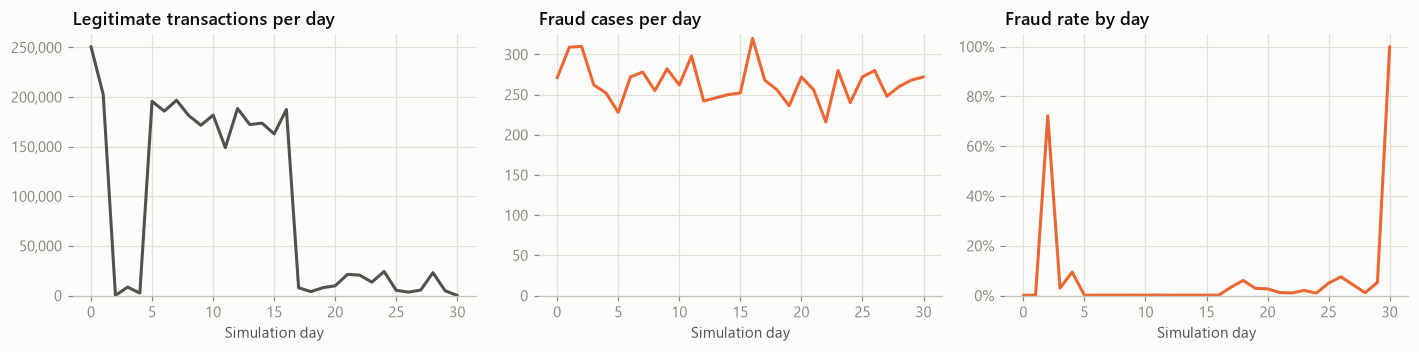

Legitimate transactions per day: first week avg 120,842, last week avg 9,445
Fraud cases per day:             first week avg 272, last week avg 263
Fraud rate:                      first week 0.22%, last week 2.71%
Fraud cases per day range from 216 to 320; days with fewer than 1,000 legitimate transactions: [2, 30]
Highest daily fraud rate: 100% (day 30)


In [8]:
day = (d["step"] - 1) // 24
daily = pd.DataFrame({"transactions": d.groupby(day).size(), "frauds": d.groupby(day)["isFraud"].sum()})
daily["legit"] = daily["transactions"] - daily["frauds"]
daily["fraud_rate"] = daily["frauds"] / daily["transactions"]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.3))
panels = [("legit", "Legitimate transactions per day", INK_2, thousands),
          ("frauds", "Fraud cases per day", ORANGE, thousands),
          ("fraud_rate", "Fraud rate by day", ORANGE, FuncFormatter(lambda v, _: f"{v:.0%}"))]
for ax, (col, title, color, fmt) in zip(axes, panels):
    ax.plot(daily.index, daily[col], color=color)
    ax.set_title(title)
    ax.set_xlabel("Simulation day")
    ax.yaxis.set_major_formatter(fmt)
    ax.set_ylim(bottom=0)
fig.tight_layout()
save_fig(fig, "fraud_time_structure.png")
plt.show()

first_week, last_week = daily.iloc[:7], daily.iloc[-7:]
print(f"Legitimate transactions per day: first week avg {first_week['legit'].mean():,.0f}, last week avg {last_week['legit'].mean():,.0f}")
print(f"Fraud cases per day:             first week avg {first_week['frauds'].mean():,.0f}, last week avg {last_week['frauds'].mean():,.0f}")
print(f"Fraud rate:                      first week {first_week['frauds'].sum() / first_week['transactions'].sum():.2%}, last week {last_week['frauds'].sum() / last_week['transactions'].sum():.2%}")
print(f"Fraud cases per day range from {int(daily['frauds'].min())} to {int(daily['frauds'].max())}; days with fewer than 1,000 legitimate transactions: {daily.index[daily['legit'] < 1000].tolist()}")
print(f"Highest daily fraud rate: {daily['fraud_rate'].max():.0%} (day {int(daily['fraud_rate'].idxmax())})")

**What this means.** Legitimate traffic is far from steady: it nearly disappears on a few days (listed above) and drops to a small fraction of its early level in the second half of the month, while fraud keeps arriving at a roughly constant number of cases per day. The daily fraud *rate* therefore swings from well under 1% to extreme values (up to 100% on a day with no legitimate traffic), purely as an artefact of the simulator. Two consequences:

1. **The split is stratified-random, not chronological.** A chronological split would train and test on periods with very different fraud rates (see §6.6), which changes PR-AUC for reasons unrelated to model quality. (A chronological hold-out is still run as a robustness check in §6.6.)
2. **`step` is not used as a feature.** It would let a model learn "on this day, almost everything is fraud", which is a property of the simulation, not of fraud. The time-of-day (`hour`) is kept: it is a plausible real-world signal.

### 2.5 Why balance-consistency features are worth engineering

A normal transfer moves `amount` out of the origin balance and into the destination balance, so `oldbalanceOrg − amount − newbalanceOrig` and `oldbalanceDest + amount − newbalanceDest` should be 0. Let us see how often that holds for fraud and legitimate transactions.

In [9]:
tol = 0.01
mismatch = pd.DataFrame({
    "isFraud": d["isFraud"],
    "origin balance mismatch": (d["oldbalanceOrg"] - d["amount"] - d["newbalanceOrig"]).abs() > tol,
    "destination balance mismatch": (d["oldbalanceDest"] + d["amount"] - d["newbalanceDest"]).abs() > tol,
    "origin account emptied": d["newbalanceOrig"] == 0,
})
mismatch_tbl = mismatch.groupby("isFraud").mean().rename(index={0: "legitimate", 1: "fraud"})
display(mismatch_tbl.style.format("{:.1%}"))

,origin balance mismatch,destination balance mismatch,origin account emptied
isFraud,,,
legitimate,90.5%,22.6%,90.1%
fraud,0.5%,56.5%,98.1%


The two mismatch flags separate the classes strongly, and in an unusual way: fraudulent transactions almost never have an origin-balance mismatch, while most legitimate ones do, and the destination side is the other way round. ("Account emptied" is common in both classes but more so among frauds.) These simple bookkeeping relations are exactly what a linear model cannot compute on its own from raw balances (it cannot subtract one column from another unless we hand it the difference), but a tree ensemble can approximate. That is the basis of the ablation in §6.

## 3. Features and split

**Two feature sets**, so that the effect of feature engineering can be separated from the effect of the model:

| Set | Columns |
|---|---|
| **raw** | `isTransfer` (type as 0/1), `amount`, `oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, `newbalanceDest` |
| **engineered** | raw + `errorBalanceOrig`, `errorBalanceDest`, `origEmptied`, `hour` |

**Excluded on purpose:** `nameOrig`, `nameDest` (identifiers), `step` (simulation artefact, see §2.4) and `isFlaggedFraud` (the simulator's own rule output; used only as a baseline). All engineered features use only the transaction's own fields, so nothing from the label leaks into them.

In [10]:
def make_features(frame):
    X = pd.DataFrame({
        "isTransfer": (frame["type"] == "TRANSFER").astype("int8"),
        "amount": frame["amount"],
        "oldbalanceOrg": frame["oldbalanceOrg"],
        "newbalanceOrig": frame["newbalanceOrig"],
        "oldbalanceDest": frame["oldbalanceDest"],
        "newbalanceDest": frame["newbalanceDest"],
    })
    raw_cols = list(X.columns)
    X["errorBalanceOrig"] = (frame["oldbalanceOrg"] - frame["amount"] - frame["newbalanceOrig"]).round(2)
    X["errorBalanceDest"] = (frame["oldbalanceDest"] + frame["amount"] - frame["newbalanceDest"]).round(2)
    X["origEmptied"] = (frame["newbalanceOrig"] == 0).astype("int8")
    X["hour"] = ((frame["step"] - 1) % 24).astype("int8")
    return X, raw_cols, list(X.columns)


X, RAW, ENG = make_features(d)
y = d["isFraud"].to_numpy()
flag = d["isFlaggedFraud"].to_numpy()
print(f"raw features ({len(RAW)}): {RAW}")
print(f"engineered features ({len(ENG)}): {ENG}")

raw features (6): ['isTransfer', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
engineered features (10): ['isTransfer', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrig', 'errorBalanceDest', 'origEmptied', 'hour']


**Split (70 / 15 / 15, stratified on the label, fixed seed).**
- *train* — fit models;
- *validation* — early stopping for XGBoost and choosing each model's decision threshold;
- *test* — touched once, for the final comparison.

In [11]:
idx = np.arange(len(d))
train_idx, rest_idx = train_test_split(idx, test_size=0.30, stratify=y, random_state=SEED)
val_idx, test_idx = train_test_split(rest_idx, test_size=0.50, stratify=y[rest_idx], random_state=SEED)

y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]
split_tbl = pd.DataFrame({
    "rows": [len(train_idx), len(val_idx), len(test_idx)],
    "frauds": [y_train.sum(), y_val.sum(), y_test.sum()],
}, index=["train", "validation", "test"])
split_tbl["fraud_rate"] = split_tbl["frauds"] / split_tbl["rows"]
display(split_tbl.style.format({"rows": "{:,}", "frauds": "{:,}", "fraud_rate": "{:.3%}"}))

# Data-quality check: test-set frauds whose six raw feature values are identical to some training transaction.
row_hash = pd.util.hash_pandas_object(X[RAW], index=False).to_numpy()
fraud_test = test_idx[y_test == 1]
has_twin = np.isin(row_hash[fraud_test], row_hash[train_idx])
twin_amounts = d["amount"].iloc[fraud_test[has_twin]].value_counts()
note = f"{int(has_twin.sum())} of the {len(fraud_test):,} test frauds ({has_twin.mean():.1%}) have a training transaction with exactly the same six raw feature values"
if len(twin_amounts):
    note += f"; the most common amount among them is {twin_amounts.index[0]:,.0f} ({int(twin_amounts.iloc[0])} cases)"
display(Markdown("**Data-quality check.** " + note + ". Such cases are easy to memorise, but they are a small share of the test frauds, so they cannot materially change the metrics."))

,rows,frauds,fraud_rate
train,"1,939,286","5,749",0.296%
validation,"415,561","1,232",0.296%
test,"415,562","1,232",0.296%


**Data-quality check.** 12 of the 1,232 test frauds (1.0%) have a training transaction with exactly the same six raw feature values; the most common amount among them is 10,000,000 (11 cases). Such cases are easy to memorise, but they are a small share of the test frauds, so they cannot materially change the metrics.

## 4. Baselines

### 4.1 Evaluation helpers
All models are scored the same way. **PR-AUC** and **ROC-AUC** are threshold-free; precision / recall / F1 need a threshold, which is **chosen on the validation set** (the one that maximises F1) and then applied unchanged to the test set.

In [12]:
def best_f1_threshold(y_true, score):
    """Score threshold with the highest F1 on the given labelled set."""
    p, r, thr = precision_recall_curve(y_true, score)
    f1 = 2 * p[:-1] * r[:-1] / np.clip(p[:-1] + r[:-1], 1e-12, None)
    return float(thr[np.argmax(f1)])


def evaluate(name, y_true, score, threshold, features="", fit_seconds=np.nan):
    pred = score >= threshold
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn)
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {"model": name, "features": features,
            "PR-AUC": average_precision_score(y_true, score), "ROC-AUC": roc_auc_score(y_true, score),
            "precision": precision, "recall": recall, "F1": f1, "accuracy": (tp + tn) / len(y_true),
            "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn), "fit_seconds": fit_seconds}


def timed_fit(model, X_fit, y_fit, **fit_kwargs):
    t = time.time()
    model.fit(X_fit, y_fit, **fit_kwargs)
    return model, time.time() - t

### 4.2 Naive baseline — "always not fraud"

In [13]:
naive, naive_s = timed_fit(DummyClassifier(strategy="most_frequent"), X.iloc[train_idx][RAW], y_train)
naive_test = naive.predict_proba(X.iloc[test_idx][RAW])[:, 1]
res_naive = evaluate("Naive (always not fraud)", y_test, naive_test, 0.5, "none", naive_s)
print(f"Test accuracy {res_naive['accuracy']:.2%}  |  recall {res_naive['recall']:.0%}  |  PR-AUC {res_naive['PR-AUC']:.4f} (equals the fraud rate {y_test.mean():.4f})")

Test accuracy 99.70%  |  recall 0%  |  PR-AUC 0.0030 (equals the fraud rate 0.0030)


### 4.3 Rule baseline — the simulator's `isFlaggedFraud`
This is the business rule that ships with the dataset. It needs no training.

In [14]:
res_rule = evaluate("Rule (isFlaggedFraud)", y_test, flag[test_idx].astype(float), 0.5, "rule output")
print(f"Rule flags {int(flag[test_idx].sum())} test transactions; precision {res_rule['precision']:.0%}, recall {res_rule['recall']:.2%}, PR-AUC {res_rule['PR-AUC']:.4f}")

Rule flags 4 test transactions; precision 100%, recall 0.32%, PR-AUC 0.0062


### 4.4 Simple model — logistic regression
A fair simple baseline: money amounts and balances are heavy-tailed, so inputs go through a signed log transform and standard scaling, and `class_weight="balanced"` handles the imbalance. It is fitted on both feature sets.

In [15]:
def signed_log1p(a):
    return np.sign(a) * np.log1p(np.abs(a))


def make_logreg():
    return make_pipeline(FunctionTransformer(signed_log1p), StandardScaler(),
                         LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEED))


baselines = {}
for label, cols_ in (("raw", RAW), ("engineered", ENG)):
    model, secs = timed_fit(make_logreg(), X.iloc[train_idx][cols_], y_train)
    thr = best_f1_threshold(y_val, model.predict_proba(X.iloc[val_idx][cols_])[:, 1])
    score_test = model.predict_proba(X.iloc[test_idx][cols_])[:, 1]
    baselines[label] = {"model": model, "thr": thr, "score": score_test,
                        "res": evaluate("Logistic regression", y_test, score_test, thr, label, secs)}

pd.DataFrame([baselines[k]["res"] for k in baselines])[["model", "features", "PR-AUC", "ROC-AUC", "precision", "recall", "F1", "fit_seconds"]]

,model,features,PR-AUC,ROC-AUC,precision,recall,F1,fit_seconds
0,Logistic regression,raw,0.5495,0.9923,0.6465,0.4513,0.5315,6.4221
1,Logistic regression,engineered,0.9697,0.9985,0.9063,0.9732,0.9386,9.2828


Logistic regression on the **raw** features is a poor detector (PR-AUC far below 1 even though ROC-AUC looks excellent — a typical symptom of heavy imbalance, where ROC-AUC is too forgiving). Once the balance-consistency features are supplied, it becomes a much stronger baseline. Both versions are kept, so the comparison with XGBoost is not made against a strawman.

## 5. XGBoost: tuning and final fit

### 5.1 Why XGBoost, and how imbalance is handled
Gradient-boosted trees fit non-linear interactions (such as "balance went to zero **and** amount equals the old balance") without feature crafting, and `tree_method="hist"` makes them fast on millions of rows. Imbalance is handled with `scale_pos_weight` (the weight on the fraud class), which is itself one of the tuned parameters.

### 5.2 Hyper-parameter search
- **Method:** `RandomizedSearchCV`, 3-fold stratified cross-validation, scoring = **average precision** (PR-AUC).
- **Data:** a stratified 30% sample of the *training* set (keeps the search to a few minutes; the validation and test sets are not involved).
- **Search space:** the basic parameters below. `scale_pos_weight` is tried at 1 (no re-weighting), √ratio and the full negative:positive ratio.

In [16]:
N_ITER = 20

ratio = (y_train == 0).sum() / (y_train == 1).sum()
param_space = {
    "n_estimators": [150, 300, 500],
    "max_depth": [3, 4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 5, 10],
    "scale_pos_weight": [1.0, round(float(np.sqrt(ratio)), 1), round(float(ratio), 1)],
}

search_idx, _ = train_test_split(np.arange(len(train_idx)), train_size=0.30, stratify=y_train, random_state=SEED)
X_search, y_search = X.iloc[train_idx][ENG].iloc[search_idx], y_train[search_idx]
print(f"Search sample: {len(X_search):,} rows, {int(y_search.sum()):,} frauds; negative:positive ratio in train = {ratio:,.1f}")

search = RandomizedSearchCV(
    XGBClassifier(tree_method="hist", eval_metric="aucpr", n_jobs=-1, random_state=SEED),
    param_distributions=param_space, n_iter=N_ITER, scoring="average_precision",
    cv=StratifiedKFold(3, shuffle=True, random_state=SEED), random_state=SEED, n_jobs=1, refit=False)

t0 = time.time()
search.fit(X_search, y_search)
print(f"{N_ITER} configurations x 3 folds searched in {time.time() - t0:.0f}s")

Search sample: 581,785 rows, 1,725 frauds; negative:positive ratio in train = 336.3


20 configurations x 3 folds searched in 607s


In [17]:
tuning = (pd.DataFrame(search.cv_results_)
            .assign(**{p: lambda t, p=p: t[f"param_{p}"] for p in param_space})
            .sort_values("rank_test_score")
            [["rank_test_score", "mean_test_score", "std_test_score", *param_space]]
            .rename(columns={"rank_test_score": "rank", "mean_test_score": "cv_PR-AUC", "std_test_score": "cv_std"}))
tuning.to_csv(REPORT_DIR / "xgboost_tuning_results.csv", index=False)

display(Markdown("**Top 5 configurations** (mean cross-validated PR-AUC ± std across folds):"))
display(tuning.head(5).style.format({"cv_PR-AUC": "{:.4f}", "cv_std": "{:.4f}"}).format("{:g}", subset=list(param_space)).hide(axis="index"))
print(f"Spread across all {len(tuning)} configurations: PR-AUC from {tuning['cv_PR-AUC'].min():.4f} to {tuning['cv_PR-AUC'].max():.4f}")
best_params = {k: (v.item() if hasattr(v, "item") else v) for k, v in search.best_params_.items()}
best_params

**Top 5 configurations** (mean cross-validated PR-AUC ± std across folds):

rank,cv_PR-AUC,cv_std,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,scale_pos_weight
1,0.9985,0.0012,500,4,0.03,0.8,0.6,5,18.3
2,0.9984,0.0011,150,3,0.05,0.6,1,1,18.3
3,0.9982,0.0013,300,6,0.05,1,1,1,18.3
4,0.9981,0.0011,500,6,0.1,1,0.6,5,18.3
5,0.9980,0.0012,500,4,0.2,1,0.6,10,18.3


Spread across all 20 configurations: PR-AUC from 0.9946 to 0.9985


{'subsample': 0.8,
 'scale_pos_weight': 18.3,
 'n_estimators': 500,
 'min_child_weight': 5,
 'max_depth': 4,
 'learning_rate': 0.03,
 'colsample_bytree': 0.6}

### 5.3 Final fit
The best configuration is refitted on the **full** training set. The number of trees is set by early stopping on the validation set (stop when validation PR-AUC has not improved for 50 rounds), so `n_estimators` from the search is only an upper bound for the search itself. The decision threshold is again chosen on the validation set.

In [18]:
def fit_xgb(cols_):
    model = XGBClassifier(**{**best_params, "n_estimators": 2000}, tree_method="hist", eval_metric="aucpr",
                          early_stopping_rounds=50, n_jobs=-1, random_state=SEED)
    return timed_fit(model, X.iloc[train_idx][cols_], y_train,
                     eval_set=[(X.iloc[val_idx][cols_], y_val)], verbose=False)


models_xgb = {}
for label, cols_ in (("engineered", ENG), ("raw", RAW)):
    model, secs = fit_xgb(cols_)
    thr = best_f1_threshold(y_val, model.predict_proba(X.iloc[val_idx][cols_])[:, 1])
    score_test = model.predict_proba(X.iloc[test_idx][cols_])[:, 1]
    models_xgb[label] = {"model": model, "thr": thr, "score": score_test,
                         "res": evaluate("XGBoost", y_test, score_test, thr, label, secs)}
    print(f"XGBoost ({label}): {model.best_iteration + 1} trees after early stopping, fitted in {secs:.0f}s, threshold {thr:.3f}")

XGBoost (engineered): 117 trees after early stopping, fitted in 19s, threshold 0.506


XGBoost (raw): 1886 trees after early stopping, fitted in 258s, threshold 0.918


The raw-feature XGBoost reuses the hyper-parameters tuned on the engineered features (it is not separately tuned); it exists only for the ablation in §6.2.

## 6. Comparison on the untouched test set

### 6.1 Headline comparison table
Both models use the engineered features; thresholds were fixed on the validation set.

In [19]:
comparison = pd.DataFrame([res_naive, res_rule, baselines["engineered"]["res"], models_xgb["engineered"]["res"]]).set_index("model")
comparison.to_csv(REPORT_DIR / "model_comparison.csv")

shown = comparison[["features", "PR-AUC", "ROC-AUC", "precision", "recall", "F1", "accuracy", "FN", "FP", "fit_seconds"]]
display(shown.style.format({"PR-AUC": "{:.4f}", "ROC-AUC": "{:.4f}", "precision": "{:.3f}", "recall": "{:.3f}",
                            "F1": "{:.3f}", "accuracy": "{:.4%}", "FN": "{:,}", "FP": "{:,}", "fit_seconds": "{:.1f}"}, na_rep="–"))

,features,PR-AUC,ROC-AUC,precision,recall,F1,accuracy,FN,FP,fit_seconds
model,,,,,,,,,,
Naive (always not fraud),none,0.0030,0.5000,0.000,0.000,0.000,99.7035%,"1,232",0,0.2
Rule (isFlaggedFraud),rule output,0.0062,0.5016,1.000,0.003,0.006,99.7045%,"1,228",0,–
Logistic regression,engineered,0.9697,0.9985,0.906,0.973,0.939,99.9622%,33,124,9.3
XGBoost,engineered,0.9972,0.9990,1.000,0.997,0.998,99.9990%,4,0,19.0


In [20]:
xg, lr, nv, rule = (comparison.loc[k] for k in ("XGBoost", "Logistic regression", "Naive (always not fraud)", "Rule (isFlaggedFraud)"))
display(Markdown(
    f"**Reading the table.** On the test set ({len(y_test):,} transactions, {int(y_test.sum()):,} frauds):\n\n"
    f"- XGBoost: PR-AUC **{xg['PR-AUC']:.4f}**, recall **{xg['recall']:.1%}**, precision **{xg['precision']:.1%}** (F1 {xg['F1']:.3f}).\n"
    f"- Logistic regression: PR-AUC {lr['PR-AUC']:.4f}, recall {lr['recall']:.1%}, precision {lr['precision']:.1%} (F1 {lr['F1']:.3f}).\n"
    f"- Naive baseline: accuracy {nv['accuracy']:.2%} but recall {nv['recall']:.0%}; its PR-AUC ({nv['PR-AUC']:.4f}) is just the fraud rate.\n"
    f"- isFlaggedFraud rule: precision {rule['precision']:.0%} but recall only {rule['recall']:.2%} (it flags {int(rule['TP'] + rule['FP'])} transactions).\n"
))

**Reading the table.** On the test set (415,562 transactions, 1,232 frauds):

- XGBoost: PR-AUC **0.9972**, recall **99.7%**, precision **100.0%** (F1 0.998).
- Logistic regression: PR-AUC 0.9697, recall 97.3%, precision 90.6% (F1 0.939).
- Naive baseline: accuracy 99.70% but recall 0%; its PR-AUC (0.0030) is just the fraud rate.
- isFlaggedFraud rule: precision 100% but recall only 0.32% (it flags 4 transactions).


### 6.2 Ablation — does the model or the features do the work?
Each model on each feature set (same split, same threshold rule).

model,features,PR-AUC,ROC-AUC,precision,recall,F1,FN,FP
Logistic regression,raw,0.5495,0.9923,0.647,0.451,0.532,676,304
Logistic regression,engineered,0.9697,0.9985,0.906,0.973,0.939,33,124
XGBoost,raw,0.9289,0.9981,0.964,0.742,0.839,318,34
XGBoost,engineered,0.9972,0.9990,1.000,0.997,0.998,4,0


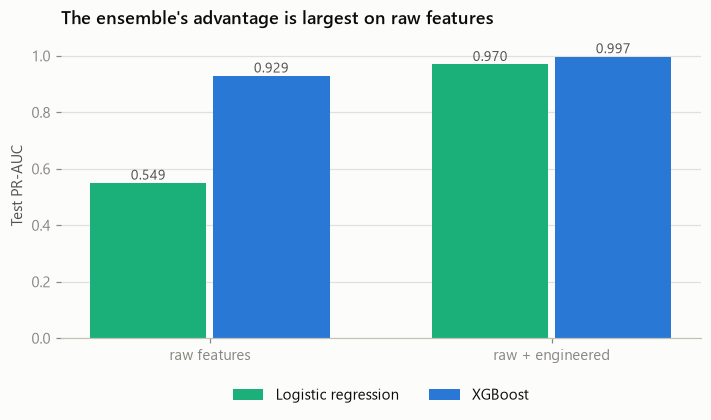

In [21]:
ablation = pd.DataFrame([baselines["raw"]["res"], baselines["engineered"]["res"],
                         models_xgb["raw"]["res"], models_xgb["engineered"]["res"]])
ablation = ablation[["model", "features", "PR-AUC", "ROC-AUC", "precision", "recall", "F1", "FN", "FP"]]
ablation.to_csv(REPORT_DIR / "ablation.csv", index=False)
display(ablation.style.format({"PR-AUC": "{:.4f}", "ROC-AUC": "{:.4f}", "precision": "{:.3f}", "recall": "{:.3f}",
                               "F1": "{:.3f}", "FN": "{:,}", "FP": "{:,}"}).hide(axis="index"))

pivot = ablation.pivot(index="features", columns="model", values="PR-AUC").loc[["raw", "engineered"]]
fig, ax = plt.subplots(figsize=(7.5, 3.6))
x = np.arange(len(pivot))
w = 0.34
for off, (name, color) in zip((-w / 2 - 0.01, w / 2 + 0.01), (("Logistic regression", AQUA), ("XGBoost", BLUE))):
    bars = ax.bar(x + off, pivot[name], width=w, color=color, label=name)
    for b_, v in zip(bars, pivot[name]):
        ax.text(b_.get_x() + b_.get_width() / 2, v + 0.012, f"{v:.3f}", ha="center", color=INK_2, fontsize=9)
ax.set_xticks(x, ["raw features", "raw + engineered"])
ax.set_ylim(0, 1.08)
ax.set_ylabel("Test PR-AUC")
ax.set_title("The ensemble's advantage is largest on raw features")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
save_fig(fig, "fraud_ablation_pr_auc.png")
plt.show()

### 6.3 Precision–recall curves

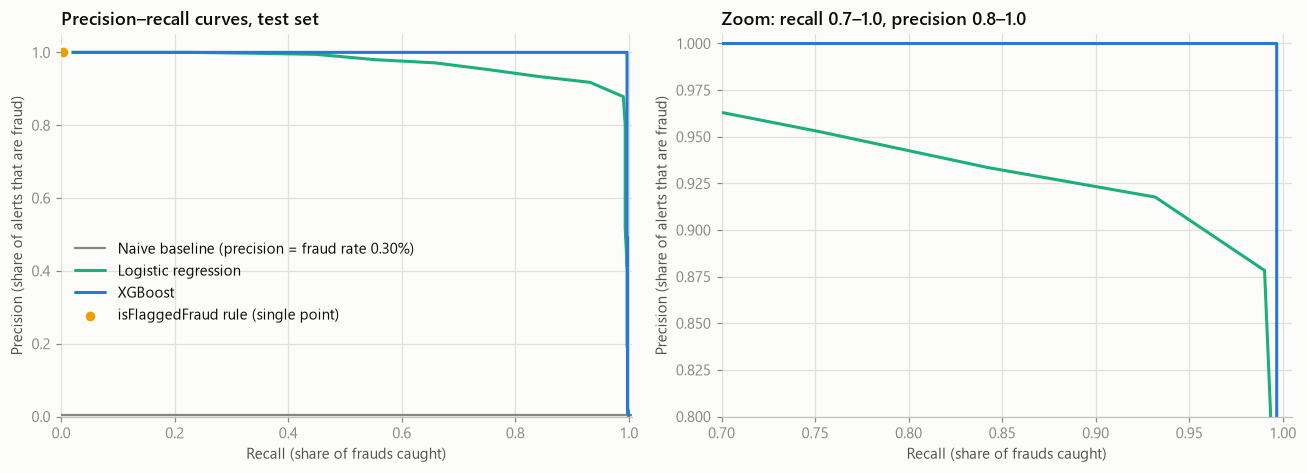

In [22]:
def curve(score):
    p, r, _ = precision_recall_curve(y_test, score)
    keep = np.unique(np.linspace(0, len(p) - 1, 3000).astype(int))
    return r[keep], p[keep]


fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, zoom in zip(axes, (False, True)):
    ax.axhline(y_test.mean(), color=MUTED, lw=1.5, label=f"Naive baseline (precision = fraud rate {y_test.mean():.2%})")
    r_, p_ = curve(baselines["engineered"]["score"])
    ax.plot(r_, p_, color=AQUA, label="Logistic regression")
    r_, p_ = curve(models_xgb["engineered"]["score"])
    ax.plot(r_, p_, color=BLUE, label="XGBoost")
    ax.scatter([rule["recall"]], [rule["precision"]], s=70, color=YELLOW, edgecolor=SURFACE, linewidth=2, zorder=5,
               label="isFlaggedFraud rule (single point)")
    ax.set_xlabel("Recall (share of frauds caught)")
    ax.set_ylabel("Precision (share of alerts that are fraud)")
    if zoom:
        ax.set_xlim(0.7, 1.005); ax.set_ylim(0.8, 1.005)
        ax.set_title("Zoom: recall 0.7–1.0, precision 0.8–1.0")
    else:
        ax.set_xlim(0, 1.005); ax.set_ylim(0, 1.05)
        ax.set_title("Precision–recall curves, test set")
        ax.legend(loc="center left", bbox_to_anchor=(0.0, 0.35))
fig.tight_layout()
save_fig(fig, "fraud_pr_curves.png")
plt.show()

### 6.4 What kinds of errors does each model make?
Missed frauds (false negatives) and false alarms (false positives) at each model's validation-chosen threshold.

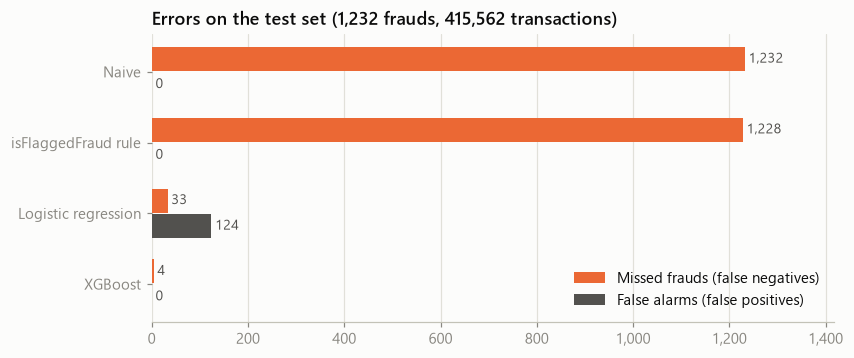

,FN,FP
Naive,1232,0
isFlaggedFraud rule,1228,0
Logistic regression,33,124
XGBoost,4,0


In [23]:
err = comparison[["FN", "FP"]].copy()
err.index = ["Naive", "isFlaggedFraud rule", "Logistic regression", "XGBoost"]
fig, ax = plt.subplots(figsize=(8, 3.4))
yy = np.arange(len(err))[::-1]
h = 0.34
b1 = ax.barh(yy + h / 2 + 0.01, err["FN"], height=h, color=ORANGE, label="Missed frauds (false negatives)")
b2 = ax.barh(yy - h / 2 - 0.01, err["FP"], height=h, color=INK_2, label="False alarms (false positives)")
for bars in (b1, b2):
    for b_ in bars:
        ax.text(b_.get_width() + 8, b_.get_y() + b_.get_height() / 2, f"{int(b_.get_width()):,}", va="center", color=INK_2, fontsize=9)
ax.set_yticks(yy, err.index)
ax.set_xlim(0, max(err["FN"].max(), err["FP"].max()) * 1.15)
ax.set_title(f"Errors on the test set ({int(y_test.sum()):,} frauds, {len(y_test):,} transactions)")
ax.xaxis.set_major_formatter(thousands)
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right")
save_fig(fig, "fraud_error_counts.png")
plt.show()
display(err)

### 6.5 Is the XGBoost advantage real? A paired bootstrap
The test set contains only a limited number of frauds, so a difference in PR-AUC could be noise. The test set is resampled 1,000 times (Poisson bootstrap, same resample for both models), PR-AUC is recomputed for each model, and the 95% interval of the difference is reported. The weighted PR-AUC below handles tied scores like scikit-learn does; a check against `average_precision_score` is printed first.

In [24]:
class WeightedAP:
    """Average precision under per-row integer weights; ties in the score are grouped (as in scikit-learn)."""

    def __init__(self, y_true, score):
        self.order = np.argsort(-score, kind="stable")
        s = score[self.order]
        self.y = y_true[self.order].astype(float)
        self.ends = np.r_[np.flatnonzero(np.diff(s) != 0), len(s) - 1]

    def __call__(self, w):
        ws = w[self.order]
        tp = np.cumsum(ws * self.y)[self.ends]
        seen = np.cumsum(ws)[self.ends]
        precision = np.divide(tp, seen, out=np.zeros_like(tp), where=seen > 0)
        gain = np.diff(np.r_[0.0, tp])
        return float(np.sum(gain / tp[-1] * precision))


ap_xgb = WeightedAP(y_test, models_xgb["engineered"]["score"])
ap_lr = WeightedAP(y_test, baselines["engineered"]["score"])
ones = np.ones(len(y_test))
print(f"check  XGBoost: weighted {ap_xgb(ones):.6f} vs sklearn {xg['PR-AUC']:.6f}   |   "
      f"logistic: weighted {ap_lr(ones):.6f} vs sklearn {lr['PR-AUC']:.6f}")

rng = np.random.default_rng(SEED)
B = 1000
boot = np.empty((B, 2))
for b_ in range(B):
    w = rng.poisson(1.0, len(y_test)).astype(float)
    boot[b_] = ap_xgb(w), ap_lr(w)
assert not np.isnan(boot).any()
diff = boot[:, 0] - boot[:, 1]
lo, hi = np.percentile(diff, [2.5, 97.5])
share = float((diff > 0).mean())
print(f"PR-AUC difference (XGBoost - logistic regression): observed {xg['PR-AUC'] - lr['PR-AUC']:+.4f}, 95% bootstrap interval [{lo:+.4f}, {hi:+.4f}]")
print(f"XGBoost scored higher in {share:.1%} of {B} resamples")

check  XGBoost: weighted 0.997184 vs sklearn 0.997184   |   logistic: weighted 0.969666 vs sklearn 0.969666


PR-AUC difference (XGBoost - logistic regression): observed +0.0275, 95% bootstrap interval [+0.0215, +0.0340]
XGBoost scored higher in 100.0% of 1000 resamples


### 6.6 Robustness — chronological hold-out
Because the stratified split mixes all weeks, this check trains on the earliest ~80% of transactions (by `step`) and tests on the latest ~20%, using the tuned XGBoost settings and the same number of trees as in §5.3. As §2.4 explains, the fraud rate in the later period is much higher, so the *absolute* PR-AUC values are not comparable with §6.1 — only the **ordering of models** is of interest.

In [25]:
cum_rows = d.groupby("step").size().cumsum()
cutoff = int(cum_rows.index[(cum_rows / cum_rows.iloc[-1] >= 0.80).argmax()])
is_train = (d["step"] <= cutoff).to_numpy()
y_tr_c, y_te_c = y[is_train], y[~is_train]

lr_c, _ = timed_fit(make_logreg(), X[is_train][ENG], y_tr_c)
xgb_c, _ = timed_fit(XGBClassifier(**{**best_params, "n_estimators": models_xgb["engineered"]["model"].best_iteration + 1},
                                   tree_method="hist", n_jobs=-1, random_state=SEED), X[is_train][ENG], y_tr_c)

rows = []
for name, model in (("Logistic regression", lr_c), ("XGBoost", xgb_c)):
    s_ = model.predict_proba(X[~is_train][ENG])[:, 1]
    rows.append({"model": name, "PR-AUC": average_precision_score(y_te_c, s_), "ROC-AUC": roc_auc_score(y_te_c, s_)})
robust = pd.DataFrame(rows).set_index("model")
display(Markdown(f"Train: steps ≤ {cutoff} ({int(is_train.sum()):,} rows, fraud rate {y_tr_c.mean():.2%}). "
                 f"Test: later steps ({int((~is_train).sum()):,} rows, fraud rate {y_te_c.mean():.2%}; the naive PR-AUC is therefore {y_te_c.mean():.4f})."))
display(robust.style.format("{:.4f}"))

Train: steps ≤ 354 (2,217,905 rows, fraud rate 0.18%). Test: later steps (552,504 rows, fraud rate 0.77%; the naive PR-AUC is therefore 0.0077).

,PR-AUC,ROC-AUC
model,,
Logistic regression,0.9960,0.9984
XGBoost,0.9999,1.0000


### 6.7 Which features does XGBoost rely on?

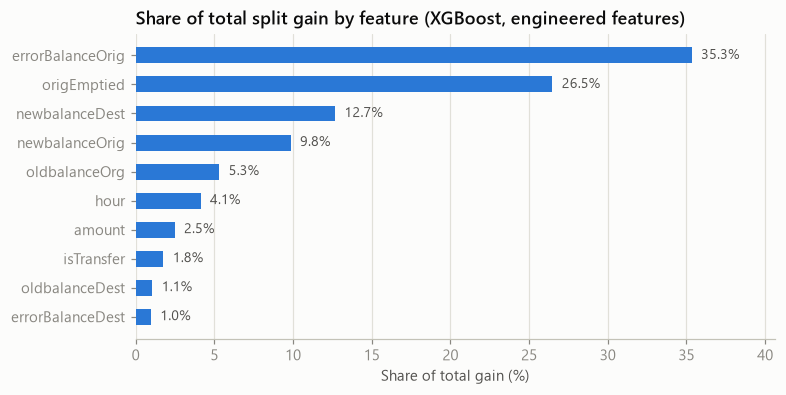

In [26]:
gain = pd.Series(models_xgb["engineered"]["model"].get_booster().get_score(importance_type="gain"))
gain = (gain / gain.sum()).reindex(ENG).fillna(0).sort_values()

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.barh(gain.index, gain.values * 100, height=0.55, color=BLUE)
for i, v in enumerate(gain.values):
    ax.text(v * 100 + 0.6, i, f"{v:.1%}", va="center", color=INK_2, fontsize=9)
ax.set_title("Share of total split gain by feature (XGBoost, engineered features)")
ax.set_xlabel("Share of total gain (%)")
ax.set_xlim(0, gain.max() * 100 * 1.15)
ax.grid(axis="y", visible=False)
save_fig(fig, "fraud_feature_importance.png")
plt.show()

## 7. Conclusions and limitations

### 7.1 Pass criterion — "the ensemble outperforms the naive baseline"

In [27]:
ok_naive = xg["PR-AUC"] > nv["PR-AUC"] and xg["recall"] > nv["recall"]
ok_lr = xg["PR-AUC"] > lr["PR-AUC"]
robust_ok = robust.loc["XGBoost", "PR-AUC"] > robust.loc["Logistic regression", "PR-AUC"]
abl = ablation.set_index(["model", "features"])["PR-AUC"]
verdict = [
    f"- **Ensemble vs naive baseline: {'PASS' if ok_naive else 'FAIL'}.** XGBoost PR-AUC {xg['PR-AUC']:.4f} vs {nv['PR-AUC']:.4f}; "
    f"recall {xg['recall']:.1%} vs {nv['recall']:.0%}. The naive model's {nv['accuracy']:.2%} accuracy is not evidence of skill, since it catches no fraud.",
    f"- **Ensemble vs logistic regression: {'XGBoost higher' if ok_lr else 'no advantage'}.** PR-AUC {xg['PR-AUC']:.4f} vs {lr['PR-AUC']:.4f} "
    f"(difference {xg['PR-AUC'] - lr['PR-AUC']:+.4f}, 95% bootstrap interval [{lo:+.4f}, {hi:+.4f}]; higher in {share:.1%} of resamples).",
    f"- **On raw features** the gap is much larger: XGBoost {abl[('XGBoost', 'raw')]:.4f} vs logistic regression {abl[('Logistic regression', 'raw')]:.4f}.",
    f"- **Chronological hold-out:** XGBoost {robust.loc['XGBoost', 'PR-AUC']:.4f} vs logistic regression {robust.loc['Logistic regression', 'PR-AUC']:.4f} "
    f"({'same ordering' if robust_ok else 'ordering differs'}).",
]
display(Markdown("\n".join(verdict)))

- **Ensemble vs naive baseline: PASS.** XGBoost PR-AUC 0.9972 vs 0.0030; recall 99.7% vs 0%. The naive model's 99.70% accuracy is not evidence of skill, since it catches no fraud.
- **Ensemble vs logistic regression: XGBoost higher.** PR-AUC 0.9972 vs 0.9697 (difference +0.0275, 95% bootstrap interval [+0.0215, +0.0340]; higher in 100.0% of resamples).
- **On raw features** the gap is much larger: XGBoost 0.9289 vs logistic regression 0.5495.
- **Chronological hold-out:** XGBoost 0.9999 vs logistic regression 0.9960 (same ordering).

### 7.2 Interpretation
**Where the ensemble's advantage comes from.**

- **Raw features: a large gap.** With only the raw columns, XGBoost reaches PR-AUC 0.929 against 0.549 for logistic regression. A fraudulent transfer here is recognisable by a *relationship* between columns (the origin balance is drained to zero by an amount equal to it, while the destination's books do not add up). Trees can carve out such interactions; a linear model on log-scaled inputs cannot subtract one column from another.
- **Engineered features: a smaller but real gap.** Handing logistic regression the balance-error features closes most of the distance (PR-AUC 0.970), which shows that feature engineering, not model capacity alone, does much of the work. XGBoost is still ahead (0.997): at validation-chosen thresholds it misses 4 of 1,232 frauds with no false alarms, while logistic regression misses 33 and raises 124 false alarms (Â§6.4). The ensemble's remaining edge is mainly precision at the same level of recall.
- **What the model uses.** The two origin-account features dominate: the origin balance error (about 35% of split gain) and whether the origin account was emptied (about 27%). Both are engineered, and engineered features together carry about two-thirds of the gain (Â§6.7).
- **Tuning mattered little.** All 20 searched configurations scored between 0.9946 and 0.9985 cross-validated PR-AUC. The top five lie within 0.0005 of each other, which is less than the fold-to-fold spread (about 0.001), and all five use the intermediate class weight (â‰ˆ 18, the square root of the class ratio). The conclusion does not depend on the exact hyper-parameters.
- **Robustness.** On a chronological hold-out the ordering is the same (XGBoost 0.9999 vs logistic regression 0.9960). Those absolute values are higher only because the later period has a much higher fraud rate (Â§6.6).

**Answer to the pass criterion.** The ensemble clearly outperforms the naive baseline (PR-AUC 0.997 vs 0.003; recall 99.7% vs 0%). It also outperforms the simpler logistic-regression baseline: by a large margin on raw features, and by a smaller but consistent margin once the balance features are engineered (the bootstrap interval in Â§6.5 quantifies this). Part of the headline score reflects how the synthetic data was generated (Â§7.3), so the *ordering* of models is the reliable result, not the near-perfect absolute values.


### 7.3 Limitations
- **Synthetic data.** PaySim is simulated. Fraud in it follows simple scripted patterns (draining an account through a transfer or cash-out), so the very high scores say little about how hard real-world fraud is. The balance-consistency features work so well partly because of how the simulator keeps its books.
- **Scope.** Metrics are for `TRANSFER` and `CASH_OUT` only; other transaction types contain no fraud in this data.
- **Threshold.** The F1-maximising threshold treats a missed fraud and a false alarm as equally costly. In practice the costs differ and the threshold should follow them.
- **Split.** A stratified random split was used because the data's time structure is a simulation artefact (§2.4). The chronological hold-out (§6.6) is a sanity check, not a replacement.
- **Tuning.** The search used a 30% sample of the training data with a modest budget; because performance is saturated, differences between top configurations are within noise (§5.2).
- **Single dataset, single seed.** No claim is made beyond this data.